In [1]:
import numpy as np
from pyscf import gto, scf, lo, mp

basis = 'ccpvdz'
atoms = '''
C    -1.0478252   -1.4216736    0.0000000
C    -1.4545034   -0.8554459    1.2062048
C    -1.4545034   -0.8554459   -1.2062048
C    -2.2667970    0.2771610    1.2069539
C    -2.6714781    0.8450211    0.0000000
C    -2.2667970    0.2771610   -1.2069539
H    -1.1338534   -1.2920593   -2.1423150
H    -2.5824943    0.7163066   -2.1437977
H    -3.3030422    1.7232700    0.0000000
H    -2.5824943    0.7163066    2.1437977
H    -1.1338534   -1.2920593    2.1423150
H    -0.4060253   -2.2919049    0.0000000
C     1.0478252    1.4216736    0.0000000
C     1.4545034    0.8554459   -1.2062048
C     1.4545034    0.8554459    1.2062048
C     2.2667970   -0.2771610   -1.2069539
C     2.6714781   -0.8450211    0.0000000
C     2.2667970   -0.2771610    1.2069539
H     0.4060253    2.2919049    0.0000000
H     1.1338534    1.2920593    2.1423150
H     2.5824943   -0.7163066    2.1437977
H     3.3030422   -1.7232700    0.0000000
H     2.5824943   -0.7163066   -2.1437977
H     1.1338534    1.2920593   -2.1423150
'''

mol = gto.M(atom = atoms,
            basis = basis,
            verbose = 4,
            unit = 'A',
            symmetry = 0,
            charge = 0,
            spin = 0,
            max_memory = 200000,
            )

mf = scf.RHF(mol).density_fit()
mf.max_cycle = 100
mf.level_shift = 0.5
mf.kernel()

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-28-generic', version='#28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Sun Aug 16 14:44:27 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 24
[INPUT] num. electrons = 84
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = A
[INPUT] Symbol           X                Y                Z      uni

np.float64(-461.4368991978969)

In [3]:
mymp = mp.MP2(mf).set_frozen()
mymp.kernel()
print(mymp.e_corr)


******** <class 'pyscf.mp.dfmp2.DFRMP2'> ********
nocc = 30, nmo = 216
frozen orbitals 12
max_memory 200000 MB (current use 792 MB)
E(DFRMP2) = -463.014971408797  E_corr = -1.57807221090008
E(SCS-DFRMP2) = -462.969210340046  E_corr = -1.53231114214943
E_corr(same-spin) = -0.416971743381532
E_corr(oppo-spin) = -1.16110046751854
-1.578072210900075


In [4]:
from pyscf.data import elements
from pyscf.lno import lnoccsd, ulnoccsd, tools
from pyscf.lno.tools import autofrag_iao
from afqmc.lno_afqmc import tools as lnoafqmc_tools

In [5]:
def name_fragments(frag_atmlist, elements, sep=""):
    """
    Build a name for each fragment by tagging every atom with its
    element symbol and its original index.

    frag_atmlist : list of lists of atom indices
    elements     : list mapping atom index -> element symbol
    sep          : string placed between atoms in a fragment name
    """
    return [sep.join(f"{elements[i]}{i}" for i in frag)
            for frag in frag_atmlist]

In [6]:
def riao_fragment(mf, nfrozen, frag_type='atom', more_loc=None):
    # IAO localization
    mol = mf.mol
    s1e = mf.get_ovlp()
    moliao = lo.iao.reference_mol(mol)
    nocc = np.count_nonzero(mf.mo_occ)
    orbocc = mf.mo_coeff[:,nfrozen:nocc]
    lo_coeff = lo.iao.iao(mol, orbocc)
    lo_coeff = lo.orth.vec_lowdin(lo_coeff, s1e)

    if frag_type == 'atom':
        frag_atmlist = tools.autofrag_atom(moliao, H2heavy=False)
    elif frag_type == 'h2heavy':
        frag_atmlist = tools.autofrag_atom(moliao, H2heavy=True)
    else:
        raise ValueError(f'Unsupported fragment type {str(frag_type)}')

    if more_loc is None:
        frag_list = autofrag_iao(moliao, 'atom', frag_atmlist)
    elif more_loc == 'boys':
        lo_coeff = lo.Boys(mol).kernel(lo_coeff)
        lo_coeff = lo.orth.vec_lowdin(lo_coeff, s1e)
        frag_list = tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
    elif more_loc == 'pm':
        lo_coeff = lo.PM(mol).kernel(lo_coeff)
        lo_coeff = lo.orth.vec_lowdin(lo_coeff, s1e)
        frag_list = tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
    else:
        raise ValueError(f'Unsupported lo type {str(more_loc)}')

    frag_name = name_fragments(frag_atmlist, moliao.elements, sep="")
    
    return lo_coeff, frag_list, frag_name

def uiao_fragment(mf, nfrozen, frag_type='atom', more_loc=None):
    # IAO localization
    mol = mf.mol
    moliao = lo.iao.reference_mol(mol)
    nocca = np.count_nonzero(mf.mo_occ[0])
    noccb = np.count_nonzero(mf.mo_occ[1])
    orbocc_a = mf.mo_coeff[0][:,nfrozen:nocca]
    orbocc_b = mf.mo_coeff[1][:,nfrozen:noccb]
    lo_coeff_a = lo.iao.iao(mol, orbocc_a)
    lo_coeff_a = lo.orth.vec_lowdin(lo_coeff_a, mf.get_ovlp())
    lo_coeff_b = lo.iao.iao(mol, orbocc_b)
    lo_coeff_b = lo.orth.vec_lowdin(lo_coeff_b, mf.get_ovlp())

    if frag_type == 'atom':
        frag_atmlist = tools.autofrag_atom(moliao, H2heavy=False)
    elif frag_type == 'h2heavy':
        frag_atmlist = tools.autofrag_atom(moliao, H2heavy=True)
    else:
        raise ValueError(f'Unsupported fragment type {str(frag_type)}')

    if more_loc is None:
        lo_coeff = [lo_coeff_a, lo_coeff_b]
        frag_list = autofrag_iao(moliao, 'atom', frag_atmlist)
        frag_list = [[i,i] for i in frag_list]
    elif more_loc == 'boys':
        lo_coeff_a = lo.Boys(mol).kernel(lo_coeff_a)
        lo_coeff_a = lo.orth.vec_lowdin(lo_coeff_a, s1e)
        lo_coeff_b = lo.Boys(mol).kernel(lo_coeff_b)
        lo_coeff_b = lo.orth.vec_lowdin(lo_coeff_b, s1e)
        lo_coeff = [lo_coeff_a, lo_coeff_b]
        frag_list = tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
    elif more_loc == 'pm':
        lo_coeff_a = lo.PM(mol).kernel(lo_coeff_a)
        lo_coeff_a = lo.orth.vec_lowdin(lo_coeff_a, s1e)
        lo_coeff_b = lo.PM(mol).kernel(lo_coeff_b)
        lo_coeff_b = lo.orth.vec_lowdin(lo_coeff_b, s1e)
        lo_coeff = [lo_coeff_a, lo_coeff_b]
        frag_list = tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
    else:
        raise ValueError(f'Unsupported lo type {str(more_loc)}')

    frag_name = name_fragments(frag_atmlist, moliao.elements, sep="")

    return lo_coeff, frag_list, frag_name

def iao_fragment(mf, nfrozen=None, frag_type='atom', more_loc=None):
    if nfrozen is None:
        nfrozen = elements.chemcore(mol)

    if isinstance(mf, scf.rhf.RHF):
        return riao_fragment(mf, nfrozen, frag_type, more_loc)

    elif isinstance(mf, scf.uhf.UHF):
        return uiao_fragment(mf, nfrozen, frag_type, more_loc)

In [7]:
from afqmc.lno_afqmc import lno_afqmc
import lno_tools
from jax import random

def run_lno(mf,
            lo_coeff, 
            frag_list,
            frag_name,
            nfrozen = 0,
            lno_thresh = 1e-6,
            qmc_options = {}, 
            chol_cut = 1e-5, 
            target_qmc_err = 1e-3, 
            run_frag = None, 
            run_ccsd = False,
            run_qmc = False,
            ):

    print("\n ******* LNO-CALCULATION ******* \n")

    lnoafqmc_tools.check_span(mf, lo_coeff, nfrozen, thresh=1e-10)

    if isinstance(mf, scf.rhf.RHF):
        spin_type = "restricted"
        mlno = lnoccsd.LNOCCSD(mf, lo_coeff, frag_list, frozen=nfrozen).set(verbose=mf.verbose)
    elif isinstance(mf, scf.uhf.UHF):
        spin_type = "unrestricted"
        mlno = ulnoccsd.ULNOCCSD(mf, lo_coeff, frag_list, frozen=nfrozen).set(verbose=mf.verbose)
    else:
        raise TypeError(f'unsupported mean-field type: {type(mf)}')

    if isinstance(lno_thresh, float):
        mlno.lno_thresh = [lno_thresh*10, lno_thresh]
    elif isinstance(lno_thresh, (list, tuple)):
        assert len(lno_thresh) == 2
        mlno.lno_thresh = [lno_thresh[0], lno_thresh[1]]

    lno_thresh = mlno.lno_thresh
    print(f"LNO THRESHOLD = {mlno.lno_thresh}")
    lno_type = ['1h','1h']
    eris = mlno.ao2mo()

    nfrag_tot = len(frag_list)
    if run_frag is None:
        run_frag = range(nfrag_tot)

    frag_list = [frag_list[i] for i in run_frag]
    frag_name = [frag_name[i] for i in run_frag]
    nfrag_run = len(frag_list)

    lno_pct_occ = [None, None]
    lno_norb = [[None,None]] * nfrag_tot

    las_size = [None]*nfrag_run
    lno_emp = np.zeros(nfrag_run, dtype='float64')
    lno_ecc  = np.zeros(nfrag_run, dtype='float64')
    lno_eqmc  = np.zeros(nfrag_run, dtype='float64')
    lno_eqmc_err  = np.zeros(nfrag_run, dtype='float64')


    seeds = random.randint(random.PRNGKey(qmc_options["seed"]),
                           shape=(nfrag_tot,), 
                           minval=0, 
                           maxval=100*nfrag_tot
                           )
    
    qmc_options["max_error"] = target_qmc_err / np.sqrt(nfrag_tot)

    # Loop over fragment
    for ifrag, frag_idx in enumerate(run_frag):
        
        loidx = frag_list[ifrag]

        print("\n")
        width = 80
        msg = f" {spin_type} LNO-FRAGMENT {frag_idx+1}/({nfrag_run},{nfrag_tot}) "
        print(msg.center(width, '='))
        print(f"Fragment Name {frag_name[ifrag]}")

        orbloc, lno_param \
            = lno_tools.get_lnoparam(mlno, lo_coeff, lno_thresh, lno_pct_occ, lno_norb, loidx, ifrag)

        lno_coeff, lno_frozen, uocc_loc, _ \
                    = mlno.make_las(eris, orbloc, lno_type, lno_param)
        
        if isinstance(mlno._scf, scf.rhf.RHF):
            lno_frozen, maskact \
                = lnoccsd.get_maskact(lno_frozen, mlno.mo_occ.size)
        elif isinstance(mlno._scf, scf.uhf.UHF):
            lno_frozen, maskact \
                = ulnoccsd.get_maskact(lno_frozen, [mlno.mo_occ[0].size, mlno.mo_occ[1].size])
        else:
            raise TypeError(f'unsupported mean-field type: {type(mlno._scf)}')

        _, nlno = lnoafqmc_tools.split_lno(mlno, lno_coeff, lno_frozen)

        eorb_mp = lno_tools.lnomp2_kernel(mlno, lno_coeff, lno_frozen, uocc_loc, maskact, verbose=4)

        if run_ccsd:
            eorb_cc, t1, t2 = \
                lno_tools.lnoccsd_kernel(mlno, lno_coeff, lno_frozen, uocc_loc, maskact, verbose=4)
        else: eorb_cc = 0.0

        if run_qmc:
            eorb_qmc, eorb_qmc_err \
                = lno_afqmc.lnoafqmc_kernel(
                    mlno, lno_coeff, uocc_loc, lno_frozen, t1, t2, 
                    chol_cut, frag_idx, seeds, qmc_options)
            
        else: eorb_qmc = 0.0; eorb_qmc_err = 0.0

        print(f'LNO-Active Space Size     {nlno}')
        print(f'LNO-MP2 Orbital Energy    {eorb_mp:.8f}')
        print(f'LNO-CCSD Orbital Energy   {eorb_cc:.8f}')
        print(fr'LNO-AFQMC Orbital Energy  {eorb_qmc:.5f} {eorb_qmc_err:.5f}')

        las_size[ifrag] = nlno
        lno_emp[ifrag] = eorb_mp
        lno_ecc[ifrag] = eorb_cc
        lno_eqmc[ifrag] = eorb_qmc
        lno_eqmc_err[ifrag] = eorb_qmc_err

        qmc_err = np.sqrt(np.sum(np.array(lno_eqmc_err)**2))

    return np.array(las_size).max(), sum(lno_emp), sum(lno_ecc), sum(lno_eqmc), qmc_err

In [8]:
options = {
           'eql_time': 10,
           'n_prop_steps': 50,
           'n_blocks': 100,
           'n_walkers': 100,
           'mix_precision': False,
           'seed': 17,
           'walker_type': 'uhf',
           'trial': 'upt2ccsd',
           }

iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='atom', more_loc=None)

threshs = [3e-5,1e-5,3e-6,1e-6,3e-7]

las1 = np.zeros(len(threshs))
elnomp1 = np.zeros(len(threshs))
elnocc1 = np.zeros(len(threshs))
elnoqmc1 = np.zeros(len(threshs))
elnoqmc_err1 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las1[i], elnomp1[i], elnocc1[i], elnoqmc1[i], elnoqmc_err1[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )


 ******* LNO-CALCULATION ******* 

LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
LNO THRESHOLD = [0.00030000000000000003, 3e-05]


====================== restricted LNO-FRAGMENT 1/(24,24) =======================
Fragment Name C0
LO occ proj: 4 active | 1 standby | 25 orthogonal
LO vir proj: 4 active | 1 standby | 181 orthogonal
nfrozen occupied orbitals:  24
nactive occupied orbitals:  18
nactive virtual orbitals:   75
nfrozen virtual orbitals:   111
Init t2, MP2 energy = -462.167030310334  E_corr(MP2) -0.730131112436828
LNO-Active Space Size     93
LNO-MP2 Orbital Energy    -0.11202491
LNO-CCSD Orbital Energy   0.00000000
LNO-AFQMC Orbital Energy  0.00000 0.00000


====================== restricted LNO-FRAGMENT 2/(24,24) =======================
Fragment Name C1
LO occ proj: 4 active | 1 standby | 25 orthogonal
LO vir proj: 4 active | 1 standby | 181 orthogonal
nfrozen occupied orbitals:  25
nactive occupied orbitals:  17
nactive virtual 

[ 93. 119. 146. 162. 180.]
[-1.55271871 -1.56841557 -1.57551478 -1.57718805 -1.57786815]


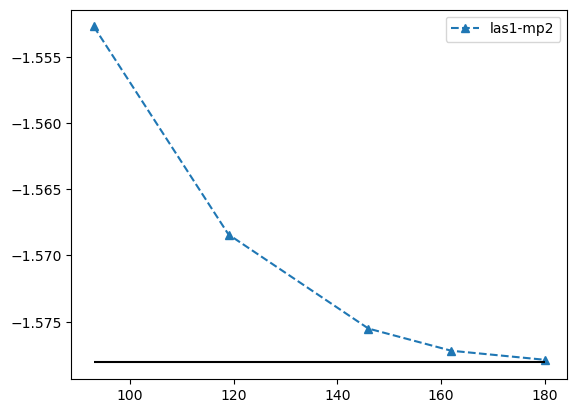

In [9]:
emp2_ref = mymp.e_corr
print(las1)
print(elnomp1)
from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "^--", color="C0", label="las1-mp2")
plt.hlines(emp2_ref, xmin=min(las1), xmax=max(las1), colors='k')
plt.legend()
plt.show()

In [10]:
iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='atom', more_loc='boys')

las2 = np.zeros(len(threshs))
elnomp2 = np.zeros(len(threshs))
elnocc2 = np.zeros(len(threshs))
elnoqmc2 = np.zeros(len(threshs))
elnoqmc_err2 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las2[i], elnomp2[i], elnocc2[i], elnoqmc2[i], elnoqmc_err2[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )



******** <class 'pyscf.lo.boys.Boys'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
Set conv_tol_grad to 0.000316228
macro= 1  f(x)= 125.33484436126  delta_f= 125.335  |g|= 4.08225  4 KF 20 Hx
macro= 2  f(x)= 121.01620110122  delta_f= -4.31864  |g|= 2.15781  4 KF 20 Hx
macro= 3  f(x)= 119.17519319721  delta_f= -1.84101  |g|= 0.635355  4 KF 20 Hx
macro= 4  f(x)= 118.86031695472  delta_f= -0.314876  |g|= 0.213758  4 KF 23 Hx
macro= 5  f(x)= 118.8407593411  delta_f= -0.0195576  |g|= 0.0737228  5 KF 25 Hx
macro= 6  f(x)= 118.82873306258  delta_f= -0.0120263  |g|= 0.151001  4 KF 23 Hx
macro= 7  f(x)= 118.81091464175  delta_f= -0.0178184  |g|= 0.125897  2 KF 6 Hx
macro= 8  f(x)= 118.79404258784  delta_f= -0.0168721  |g|= 0.107006  2 KF 3 Hx
mac

[ 93. 119. 146. 162. 180.]
[-1.55271871 -1.56841557 -1.57551478 -1.57718805 -1.57786815]
[ 94. 121. 148. 163. 183.]
[-1.55178701 -1.56915172 -1.57560263 -1.57725974 -1.57789134]


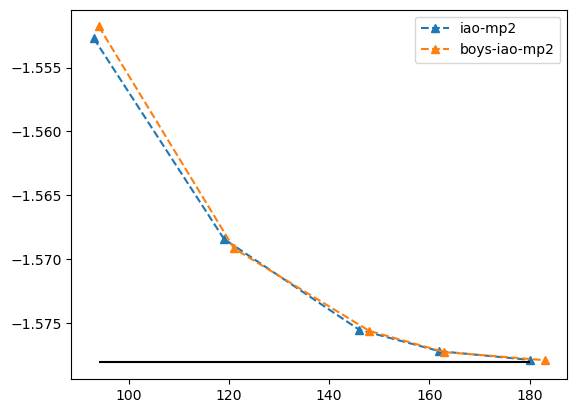

In [11]:
print(las1)
print(elnomp1)
print(las2)
print(elnomp2)
from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "^--", color="C0", label="iao-mp2")
plt.plot(las2, elnomp2, "^--", color="C1", label="boys-iao-mp2")
plt.hlines(emp2_ref, xmin=min(las2), xmax=max(las1), colors='k')
plt.legend()
plt.show()

In [12]:
iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='h2heavy', more_loc=None)

las3 = np.zeros(len(threshs))
elnomp3 = np.zeros(len(threshs))
elnocc3 = np.zeros(len(threshs))
elnoqmc3 = np.zeros(len(threshs))
elnoqmc_err3 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las3[i], elnomp3[i], elnocc3[i], elnoqmc3[i], elnoqmc_err3[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )


 ******* LNO-CALCULATION ******* 

LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
LNO THRESHOLD = [0.00030000000000000003, 3e-05]


====================== restricted LNO-FRAGMENT 1/(12,12) =======================
Fragment Name C0H11
LO occ proj: 4 active | 2 standby | 24 orthogonal
LO vir proj: 4 active | 2 standby | 180 orthogonal
nfrozen occupied orbitals:  24
nactive occupied orbitals:  18
nactive virtual orbitals:   75
nfrozen virtual orbitals:   111
Init t2, MP2 energy = -462.167521481366  E_corr(MP2) -0.730622283469514
LNO-Active Space Size     93
LNO-MP2 Orbital Energy    -0.13038974
LNO-CCSD Orbital Energy   0.00000000
LNO-AFQMC Orbital Energy  0.00000 0.00000


====================== restricted LNO-FRAGMENT 2/(12,12) =======================
Fragment Name C1H10
LO occ proj: 4 active | 2 standby | 24 orthogonal
LO vir proj: 4 active | 2 standby | 180 orthogonal
nfrozen occupied orbitals:  25
nactive occupied orbitals:  17
nactive vi

In [13]:
iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='h2heavy', more_loc='boys')

las4 = np.zeros(len(threshs))
elnomp4 = np.zeros(len(threshs))
elnocc4 = np.zeros(len(threshs))
elnoqmc4 = np.zeros(len(threshs))
elnoqmc_err4 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las4[i], elnomp4[i], elnocc4[i], elnoqmc4[i], elnoqmc_err4[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )



******** <class 'pyscf.lo.boys.Boys'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
Set conv_tol_grad to 0.000316228
macro= 1  f(x)= 125.33484436126  delta_f= 125.335  |g|= 4.08225  4 KF 20 Hx
macro= 2  f(x)= 121.01620110122  delta_f= -4.31864  |g|= 2.15781  4 KF 20 Hx
macro= 3  f(x)= 119.17519319721  delta_f= -1.84101  |g|= 0.635355  4 KF 20 Hx
macro= 4  f(x)= 118.86031695472  delta_f= -0.314876  |g|= 0.213758  4 KF 23 Hx
macro= 5  f(x)= 118.8407593411  delta_f= -0.0195576  |g|= 0.0737228  5 KF 25 Hx
macro= 6  f(x)= 118.82873306258  delta_f= -0.0120263  |g|= 0.151001  4 KF 23 Hx
macro= 7  f(x)= 118.81091464175  delta_f= -0.0178184  |g|= 0.125897  2 KF 6 Hx
macro= 8  f(x)= 118.79404258784  delta_f= -0.0168721  |g|= 0.107006  2 KF 3 Hx
mac

[ 93. 119. 146. 162. 180.]
[-1.55271871 -1.56841557 -1.57551478 -1.57718805 -1.57786815]
[ 94. 121. 148. 163. 183.]
[-1.55178701 -1.56915172 -1.57560263 -1.57725974 -1.57789134]
[ 93. 119. 147. 162. 179.]
[-1.56291048 -1.57226035 -1.57680806 -1.5776562  -1.57797249]
[ 95. 121. 148. 162. 180.]
[-1.56364876 -1.57236214 -1.57689517 -1.57763071 -1.57797055]


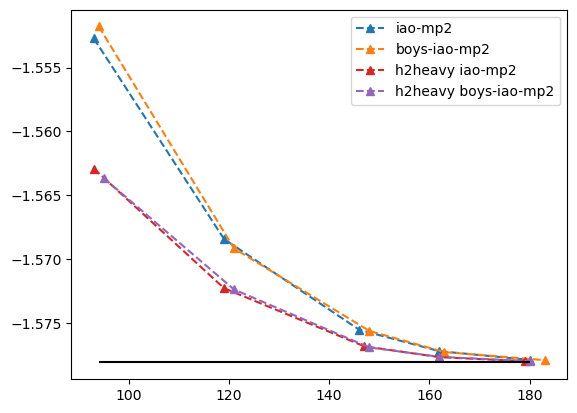

In [14]:
print(las1)
print(elnomp1)
print(las2)
print(elnomp2)
print(las3)
print(elnomp3)
print(las4)
print(elnomp4)
from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "^--", color="C0", label="iao-mp2")
plt.plot(las2, elnomp2, "^--", color="C1", label="boys-iao-mp2")
plt.plot(las3, elnomp3, "^--", color="C3", label="h2heavy iao-mp2")
plt.plot(las4, elnomp4, "^--", color="C4", label="h2heavy boys-iao-mp2")
plt.hlines(emp2_ref, xmin=min(las2), xmax=max(las1), colors='k')
plt.legend()
plt.show()

In [15]:
iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='atom', more_loc='pm')

las5 = np.zeros(len(threshs))
elnomp5 = np.zeros(len(threshs))
elnocc5 = np.zeros(len(threshs))
elnoqmc5 = np.zeros(len(threshs))
elnoqmc_err5 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las5[i], elnomp5[i], elnocc5[i], elnoqmc5[i], elnoqmc_err5[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )



******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
pop_method = meta_lowdin
Set conv_tol_grad to 0.000316228
macro= 1  f(x)= 71.50891947457  delta_f= 71.5089  |g|= 0.0674991  3 KF 9 Hx
macro= 2  f(x)= 71.51272310658  delta_f= 0.00380363  |g|= 0.0060087  3 KF 9 Hx
macro= 3  f(x)= 71.51288473215  delta_f= 0.000161626  |g|= 0.00184997  6 KF 32 Hx
macro= 4  f(x)= 71.512888874856  delta_f= 4.14271e-06  |g|= 0.000113596  2 KF 6 Hx
macro= 5  f(x)= 71.512888874893  delta_f= 3.69624e-11  |g|= 5.15635e-05  1 KF 1 Hx
macro X = 5  f(x)= 71.512888874893  |g|= 5.15635e-05  10 intor 15 KF 57 Hx

 ******* LNO-CALCULATION ******* 

LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space -

In [16]:
iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='h2heavy', more_loc='pm')

las6 = np.zeros(len(threshs))
elnomp6 = np.zeros(len(threshs))
elnocc6 = np.zeros(len(threshs))
elnoqmc6 = np.zeros(len(threshs))
elnoqmc_err6 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las6[i], elnomp6[i], elnocc6[i], elnoqmc6[i], elnoqmc_err6[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )



******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
pop_method = meta_lowdin
Set conv_tol_grad to 0.000316228
macro= 1  f(x)= 71.50891947457  delta_f= 71.5089  |g|= 0.0674991  3 KF 9 Hx
macro= 2  f(x)= 71.51272310658  delta_f= 0.00380363  |g|= 0.0060087  3 KF 9 Hx
macro= 3  f(x)= 71.51288473215  delta_f= 0.000161626  |g|= 0.00184997  6 KF 32 Hx
macro= 4  f(x)= 71.512888874856  delta_f= 4.14271e-06  |g|= 0.000113596  2 KF 6 Hx
macro= 5  f(x)= 71.512888874893  delta_f= 3.69624e-11  |g|= 5.15635e-05  1 KF 1 Hx
macro X = 5  f(x)= 71.512888874893  |g|= 5.15635e-05  10 intor 15 KF 57 Hx

 ******* LNO-CALCULATION ******* 

LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space -

[ 93. 119. 146. 162. 180.]
[-1.55271871 -1.56841557 -1.57551478 -1.57718805 -1.57786815]
[ 94. 121. 148. 163. 183.]
[-1.55178701 -1.56915172 -1.57560263 -1.57725974 -1.57789134]
[ 93. 119. 147. 162. 179.]
[-1.56291048 -1.57226035 -1.57680806 -1.5776562  -1.57797249]
[ 95. 121. 148. 162. 180.]
[-1.56364876 -1.57236214 -1.57689517 -1.57763071 -1.57797055]
[ 93. 119. 146. 162. 180.]
[-1.55245907 -1.56828997 -1.57545595 -1.57717522 -1.57786275]
[ 93. 119. 146. 162. 179.]
[-1.56301532 -1.57240283 -1.57679333 -1.57762841 -1.57797026]


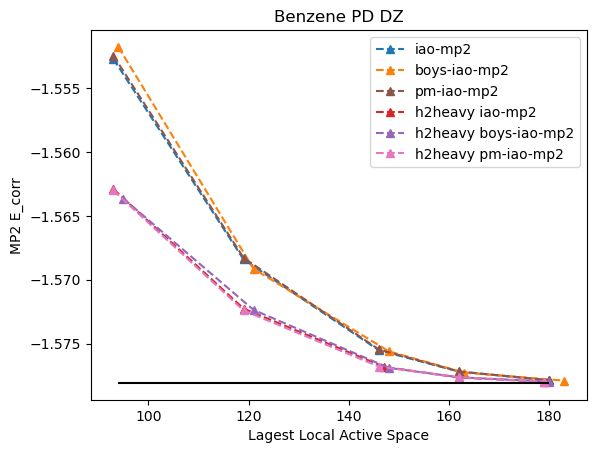

In [20]:
print(las1)
print(elnomp1)
print(las2)
print(elnomp2)
print(las3)
print(elnomp3)
print(las4)
print(elnomp4)
print(las5)
print(elnomp5)
print(las6)
print(elnomp6)

from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "^--", color="C0", label="iao-mp2")
plt.plot(las2, elnomp2, "^--", color="C1", label="boys-iao-mp2")
plt.plot(las5, elnomp5, "^--", color="C5", label="pm-iao-mp2")
plt.plot(las3, elnomp3, "^--", color="C3", label="h2heavy iao-mp2")
plt.plot(las4, elnomp4, "^--", color="C4", label="h2heavy boys-iao-mp2")
plt.plot(las6, elnomp6, "^--", color="C6", label="h2heavy pm-iao-mp2")
plt.hlines(emp2_ref, xmin=min(las2), xmax=max(las1), colors='k')
plt.legend()
plt.xlabel('Lagest Local Active Space')
plt.ylabel('MP2 E_corr')
plt.title('Benzene PD DZ')
plt.show()